Calcualted Entropy for Young Patients

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt

# ------------------ Preprocessing ------------------
# def preprocess_signal_entropy(ts: np.ndarray,
#                       fs: float = 100.0,
#                       low: float = 0.1,
#                       high: float = 3.0) -> np.ndarray:
#     """
#     Detrend, band-pass filter (0.1–3 Hz), then z-score.
#     Common preprocessing in gait entropy studies.
#     """
#     ts_d = detrend(ts)
#     b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
#     ts_f = filtfilt(b, a, ts_d)
    
#     # 3) Plot raw (detrended) vs. filtered
#     plt.figure(figsize=(8, 3))
#     plt.plot(ts_d, alpha=0.3, label="Detrended (raw)")
#     plt.plot(ts, alpha=0.7, label="Raw")
#     plt.plot(ts_f, alpha=1.0, label="Filtered")
#     plt.title("Preprocessing: Raw vs. Filtered")
#     plt.xlabel("Sample index")
#     plt.ylabel("Amplitude")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()
    # return (ts_f - np.mean(ts_f)) / np.std(ts_f)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt

def preprocess_signal_entropy(ts: np.ndarray,
                              fs: float = 100.0,
                              low: float = 0.1,
                              high: float = 3.0) -> np.ndarray:
    """
    1) Detrend (remove any linear drift).
    2) Band-pass filter between low–high Hz (here 0.1–3 Hz).
    3) Z-score the filtered signal.
    4) Plot detrended vs. raw vs. filtered for inspection.
    """
    # 1) Remove linear trend
    ts_d = detrend(ts)

    # 2) Band-pass filter
    nyq = fs / 2
    b, a = butter(4, [low/nyq, high/nyq], btype="bandpass")
    ts_f = filtfilt(b, a, ts_d)

    # 3) Z-score (zero mean, unit variance)
    # ts_z = (ts_f - np.mean(ts_f)) / np.std(ts_f)

    # 4) Plot for visual check
    plt.figure(figsize=(8, 3))
    plt.plot(ts_d, alpha=0.3, label="Detrended (raw)")
    plt.plot(ts,  alpha=0.7, label="Raw")
    plt.plot(ts_f, alpha=1.0, label="Filtered (pre–z-score)")
    plt.title("Preprocessing: Raw vs. Detrended vs. Filtered")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return the z-scored, band-passed signal for entropy
    return ts_f



# ------------------ Entropy Measures ------------------
def approximate_entropy(U: np.ndarray, m: int = 2, r: float = None) -> float:
    """
    Approximate Entropy (ApEn) with m=2, r=0.2*SD default.
    """
    U = np.asarray(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)
    def phi(mv):
        X = np.array([U[i:i+mv] for i in range(N-mv+1)])
        C = [np.mean(np.max(np.abs(X - xi), axis=1) <= r) for xi in X]
        return np.mean(np.log(C))
    return phi(m) - phi(m+1)

def sample_entropy(U: np.ndarray, m: int = 2, r: float = None) -> float:
    """
    Sample Entropy (SampEn) with m=2, r=0.2*SD default.
    """
    U = np.asarray(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)
    X  = np.array([U[i:i+m] for i in range(N-m+1)])
    X1 = np.array([U[i:i+m+1] for i in range(N-m)])
    def count_matches(Xarr):
        cnt = 0
        for i in range(len(Xarr)):
            for j in range(i+1, len(Xarr)):
                if np.max(np.abs(Xarr[i] - Xarr[j])) <= r:
                    cnt += 1
        return cnt
    B = count_matches(X)
    A = count_matches(X1)
    return np.inf if (B == 0 or A == 0) else -np.log(A / B)

# ------------------ Multiscale Entropy ------------------
def coarse_grain(ts: np.ndarray, scale: int) -> np.ndarray:
    """Non-overlapping average for MSE coarse-graining."""
    N = len(ts)
    num = N // scale
    return np.mean(ts[:num*scale].reshape(num, scale), axis=1)

def multiscale_entropy(ts: np.ndarray,
                        m: int = 2,
                        r: float = None,
                        max_scale: int = 20) -> tuple[np.ndarray, np.ndarray]:
    """
    Multiscale Entropy (MSE): SampEn on each coarse-grained series.
    """
    if r is None:
        r = 0.2 * np.std(ts)
    scales = np.arange(1, max_scale + 1)
    mse = np.array([sample_entropy(coarse_grain(ts, s), m, r) for s in scales])
    return scales, mse
    
def compute_entropy_on_acceleration(ts_disp, fs=100.0, r_factor=0.2):
    # 1) Compute velocity and acceleration
    vel = np.gradient(ts_disp, 1/fs)
    acc = np.gradient(vel,    1/fs)

    # 2) Optional band‐pass on acceleration (0.5–10 Hz):
    b, a = butter(4, [0.5/(fs/2), 10/(fs/2)], btype="bandpass")
    acc_f = filtfilt(b, a, acc)

    acc_z = (acc_f - np.mean(acc_f)) / np.std(acc_f)
    r = r_factor * np.std(acc_z)
    return approximate_entropy(acc_z, m=2, r=r), sample_entropy(acc_z, m=2, r=r)


def compute_MSE_on_acceleration(ts_disp, fs=100.0, r_factor):
    # 1) Compute velocity and acceleration
    vel = np.gradient(ts_disp, 1/fs)
    acc = np.gradient(vel,    1/fs)

    # 2) Optional band‐pass on acceleration (0.5–10 Hz):
    b, a = butter(4, [0.5/(fs/2), 10/(fs/2)], btype="bandpass")
    acc_f = filtfilt(b, a, acc)

    # 3) Z-score
    acc_z = (acc_f - np.mean(acc_f)) / np.std(acc_f)

    # 4) Entropy
    r = r_factor * np.std(acc_z)

    scales, mse = multiscale_entropy(acc_z, m=2, r=r, max_scale=20)

    return  scales, mse





# Young 13

In [99]:
import pandas as pd
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"Cereneo_SR_13_Fam_pre.4_events.csv"

# print("Data file:", data_path.resolve(), "Exists?", data_path.exists())

ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))
  # ← path to your events.csv
fs = 100.0                      # sampling frequency in Hz

# How many consecutive left‐leg strides you want:
N_STRIDES = 100
SKIP_SAMPLES = 5000 
skip_time = SKIP_SAMPLES / fs
df = pd.read_csv(events_path)

# Make sure we have the expected columns
required_cols = {'time', 'label', 'context', 'icon_id'}
if not required_cols.issubset(df.columns):
    raise ValueError(
        f"Expected columns {required_cols} in events.csv, but got {df.columns.tolist()}"
    )



left_fo_df = df[
    (df["context"] == "Left")
    & (df["label"]   == "Foot Strike")
    & (df["time"]    >= skip_time)
].copy()

left_fo_df.sort_values(by="time", inplace=True)

if len(left_fo_df) < N_STRIDES:
    raise ValueError(
        f"Found only {len(left_fo_df)} left‐leg foot‐off events, but need {N_STRIDES}."
    )

first_n = left_fo_df.iloc[:N_STRIDES]

start_time = first_n["time"].iloc[0]
end_time   = first_n["time"].iloc[-1]

print(f"Using the first {N_STRIDES} left‐leg FOOT‐OFF events:")
print(f"  Start time (1st L_FO) = {start_time:.4f} s")
print(f"  End   time ({N_STRIDES}th L_FO) = {end_time:.4f} s")

com = ds["markers"].sel(channel="COM")

fs = 100.0


for axis in ("x", "y", "z"):
    print(f"--- {axis}-axis ---")
    ts = com.sel(axis=axis).values.ravel()
    # ts = preprocess_signal_entropy(ts, fs)
    print(ts[::])
    start = int(start_time * fs)
    end = int(end_time * fs)
    print(f"Start index: {start}, End index: {end}")
    ts = ts[start:end]
    print(f"Signal length: {len(ts)} samples")
    
    
    r = 0.2
    
    
    ap_ac, samp_ac = compute_entropy_on_acceleration(ts, fs,r_factor=r)
    # mse_ac = compute_MSE_on_acceleration(ts, fs)
    print(f"ApEn   (m=2, r=0.2σ) = {ap_ac:.4f}")
    print(f"SampEn (m=2, r=0.2σ) = {samp_ac:.4f}")
    # print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse_ac}")

    

    # ap = approximate_entropy(ts, m=2, r=r)
    # print(f"ApEn   (m=2, r=0.2σ) = {ap:.4f}")
    # samp = sample_entropy(ts, m=2, r=r)
    # print(f"SampEn (m=2, r=0.2σ) = {samp:.4f}")
    # scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=15)
    # print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse}")
    

    # # Multiscale Entropy (MSE)
    # scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=4)
    # plt.figure(figsize=(6,4))
    # plt.plot(scales, mse, 'o-')
    # plt.title(f"MSE {axis}-axis (m=2, r=0.2σ)")
    # plt.xlabel("Scale")
    # plt.ylabel("MSE")
    # plt.tight_layout()
    # plt.show()
    # print()



Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Using the first 100 left‐leg FOOT‐OFF events:
  Start time (1st L_FO) = 50.8700 s
  End   time (100th L_FO) = 204.1200 s
--- x-axis ---
[39.79531711 38.36716469 36.94409393 ... 20.98832679 19.67745082
 18.29513446]
Start index: 5087, End index: 20412
Signal length: 15325 samples
ApEn   (m=2, r=0.2σ) = 0.3655
SampEn (m=2, r=0.2σ) = 0.2014
--- y-axis ---
[-29.6764637  -28.67051006 -27.69097455 ... -66.67650501 -66.19976354
 -65.6149803 ]
Start index: 5087, End index: 20412
Signal length: 15325 samples
ApEn   (m=2, r=0.2σ) = 0.4825
SampEn (m=2, r=0.2σ) = 0.3648
--- z-axis ---
[712.36361467 712.35105943 712.3585664  ... 709.07555375 707.98741749
 706.86727735]
Start index: 5087, End index: 20412
Signal length: 15325 samples
ApEn   (m=2, r=0.2σ) = 0.3503
SampEn (m=2, r=0.2σ) = 0.2028


## Post

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Using the first 20 left‐leg FOOT‐OFF events:
  Start time (1st L_FO) = 150.8900 s
  End   time (20th L_FO) = 178.8600 s
--- x-axis ---


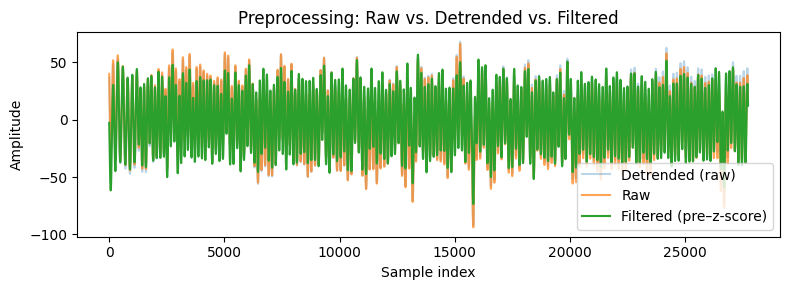

[-2.86677122 -4.16596641 -5.45729364 ... 14.34026946 13.18286574
 12.03361183]
Start index: 15088, End index: 17886
Signal length: 2798 samples
ApEn   (m=2, r=0.2σ) = 0.1227
SampEn (m=2, r=0.2σ) = 0.1221
Multiscale Entropy (m=2, r=0.2σ) = [0.12205354 0.28679104 0.37853921 0.41635786 0.45055368 0.47907142
 0.52122651 0.54476686 0.55338524 0.57323119 0.56829698 0.60287691
 0.64141151 0.68545483 0.67238519]


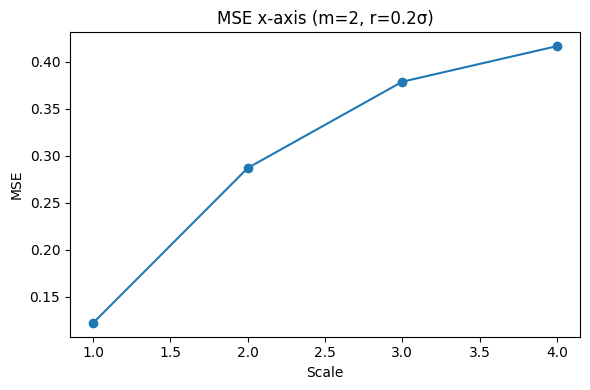


--- y-axis ---


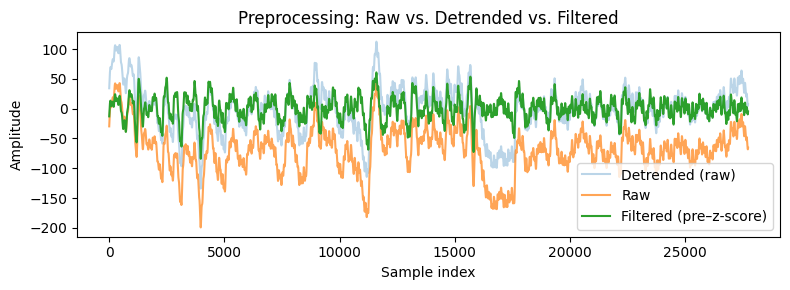

[-12.89036099 -12.09080823 -11.29601499 ...  -5.85250645  -5.36301615
  -4.87164917]
Start index: 15088, End index: 17886
Signal length: 2798 samples
ApEn   (m=2, r=0.2σ) = 0.0863
SampEn (m=2, r=0.2σ) = 0.0777
Multiscale Entropy (m=2, r=0.2σ) = [0.07768621 0.17408344 0.28028271 0.37486588 0.43860534 0.49180995
 0.53171698 0.57658717 0.62398807 0.68976961 0.73565197 0.78549532
 0.86073408 0.92489558 0.99176919]


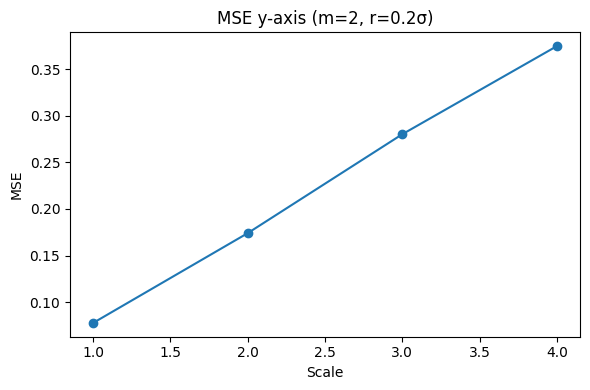


--- z-axis ---


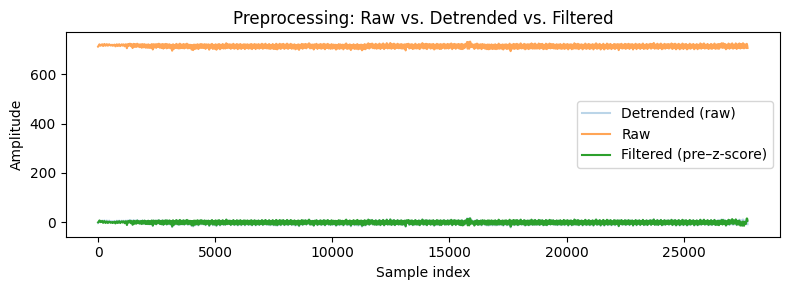

[-0.75459842 -0.7062259  -0.65585041 ...  7.48877724  6.86780305
  6.24997107]
Start index: 15088, End index: 17886
Signal length: 2798 samples
ApEn   (m=2, r=0.2σ) = 0.3234
SampEn (m=2, r=0.2σ) = 0.2659
Multiscale Entropy (m=2, r=0.2σ) = [0.2659437  0.35859527 0.4151731  0.46402595 0.50349028 0.54424274
 0.55313223 0.61687814 0.64213306 0.68103711 0.61232777 0.73111681
 0.86523556 0.70774598 0.96612311]


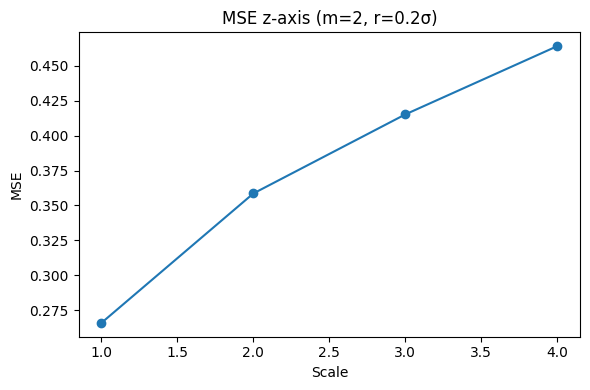

In [ ]:
import pandas as pd
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"Cereneo_SR_13_Fam_pre.4_events.csv"

# print("Data file:", data_path.resolve(), "Exists?", data_path.exists())

ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))
  # ← path to your events.csv
fs = 100.0                      # sampling frequency in Hz

# How many consecutive left‐leg strides you want:
N_STRIDES = 20
SKIP_SAMPLES = 15000
skip_time = SKIP_SAMPLES / fs
df = pd.read_csv(events_path)

# Make sure we have the expected columns
required_cols = {'time', 'label', 'context', 'icon_id'}
if not required_cols.issubset(df.columns):
    raise ValueError(
        f"Expected columns {required_cols} in events.csv, but got {df.columns.tolist()}"
    )



left_fo_df = df[
    (df["context"] == "Left")
    & (df["label"]   == "Foot Strike")
    & (df["time"]    >= skip_time)
].copy()

left_fo_df.sort_values(by="time", inplace=True)

if len(left_fo_df) < N_STRIDES:
    raise ValueError(
        f"Found only {len(left_fo_df)} left‐leg foot‐off events, but need {N_STRIDES}."
    )

first_n = left_fo_df.iloc[:N_STRIDES]

start_time = first_n["time"].iloc[0]
end_time   = first_n["time"].iloc[-1]

print(f"Using the first {N_STRIDES} left‐leg FOOT‐OFF events:")
print(f"  Start time (1st L_FO) = {start_time:.4f} s")
print(f"  End   time ({N_STRIDES}th L_FO) = {end_time:.4f} s")

com = ds["markers"].sel(channel="COM")

fs = 100.0


for axis in ("x", "y", "z"):
    print(f"--- {axis}-axis ---")
    ts_raw = com.sel(axis=axis).values.ravel()
    ts = preprocess_signal_entropy(ts_raw, fs)
    print(ts[::])
    start = int(start_time * fs)
    end = int(end_time * fs)
    print(f"Start index: {start}, End index: {end}")
    ts = ts[start:end]
    print(f"Signal length: {len(ts)} samples")
    
    
    r = 0.2 * np.std(ts)

    
    
    # ap_ac, samp_ac = compute_entropy_on_acceleration(ts, fs)
    # mse_ac = compute_MSE_on_acceleration(ts, fs)
    # print(f"ApEn   (m=2, r=0.2σ) = {ap_ac:.4f}")
    # print(f"SampEn (m=2, r=0.2σ) = {samp_ac:.4f}")
    # print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse_ac}")

    

    ap = approximate_entropy(ts, m=2, r=r)
    print(f"ApEn   (m=2, r=0.2σ) = {ap:.4f}")
    samp = sample_entropy(ts, m=2, r=r)
    print(f"SampEn (m=2, r=0.2σ) = {samp:.4f}")
    # scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=15)
    # print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse}")
    

    # Multiscale Entropy (MSE)
    # scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=4)
    # plt.figure(figsize=(6,4))
    # plt.plot(scales, mse, 'o-')
    # plt.title(f"MSE {axis}-axis (m=2, r=0.2σ)")
    # plt.xlabel("Scale")
    # plt.ylabel("MSE")
    # plt.tight_layout()
    # plt.show()
    # print()



# Patient 14

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Using the first 50 left‐leg FOOT‐OFF events:
  Start time (1st L_FO) = 50.3500 s
  End   time (50th L_FO) = 126.2500 s
--- x-axis ---


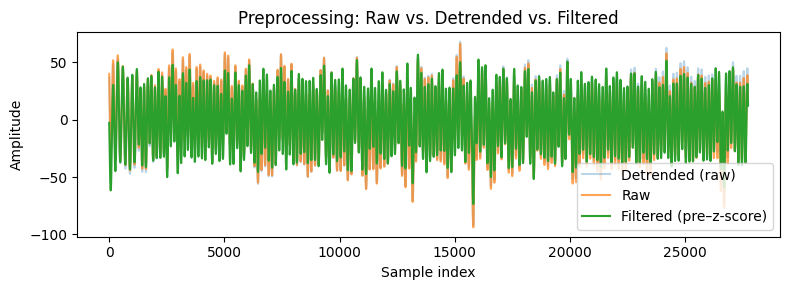

[-2.86677122 -4.16596641 -5.45729364 ... 14.34026946 13.18286574
 12.03361183]
Start index: 5035, End index: 12625
Signal length: 7590 samples
ApEn   (m=2, r=0.2σ) = 0.1248
SampEn (m=2, r=0.2σ) = 0.1203
Multiscale Entropy (m=2, r=0.2σ) = [0.12025179 0.27247734 0.34178369 0.37534003 0.4105928  0.43614631
 0.45892644 0.47417478 0.49074811 0.50736712 0.50665173 0.5054501
 0.52670117 0.53423818 0.53534553]


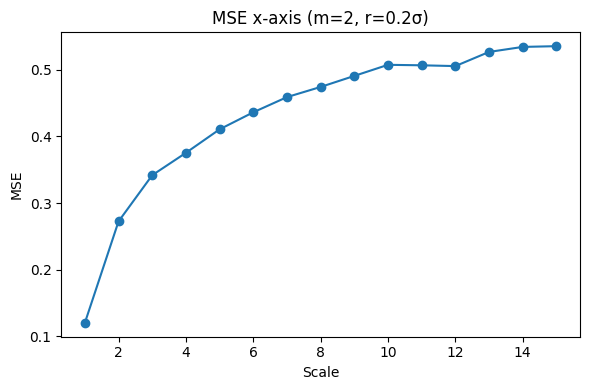


--- y-axis ---


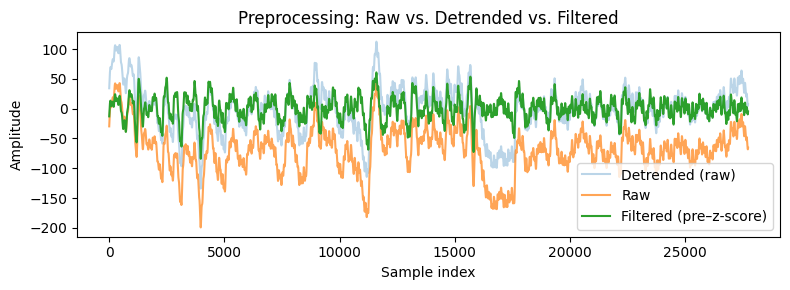

[-12.89036099 -12.09080823 -11.29601499 ...  -5.85250645  -5.36301615
  -4.87164917]
Start index: 5035, End index: 12625
Signal length: 7590 samples
ApEn   (m=2, r=0.2σ) = 0.0796
SampEn (m=2, r=0.2σ) = 0.0779
Multiscale Entropy (m=2, r=0.2σ) = [0.0778512  0.17600688 0.28798289 0.3821626  0.45282542 0.50477068
 0.54828118 0.58780217 0.64159443 0.70239268 0.76301807 0.84591798
 0.9235169  0.97629597 1.05513636]


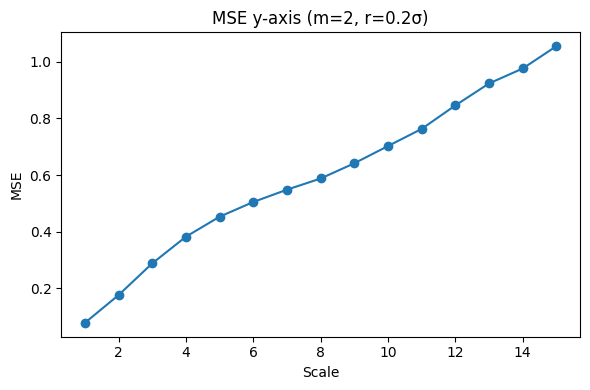


--- z-axis ---


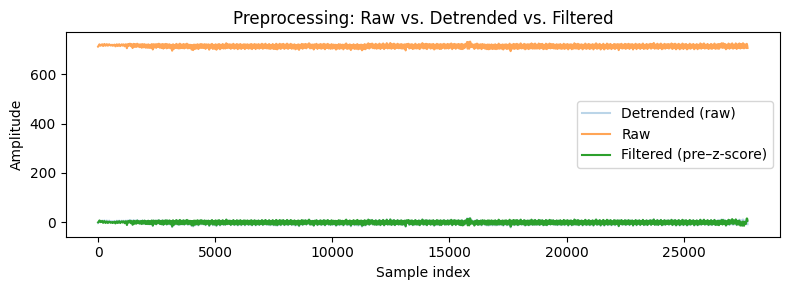

[-0.75459842 -0.7062259  -0.65585041 ...  7.48877724  6.86780305
  6.24997107]
Start index: 5035, End index: 12625
Signal length: 7590 samples
ApEn   (m=2, r=0.2σ) = 0.2965
SampEn (m=2, r=0.2σ) = 0.2575
Multiscale Entropy (m=2, r=0.2σ) = [0.25749836 0.34876171 0.41918486 0.46891995 0.50152323 0.52170446
 0.53714395 0.57127476 0.57361749 0.59971148 0.63187878 0.64510134
 0.68224918 0.66979982 0.74774436]


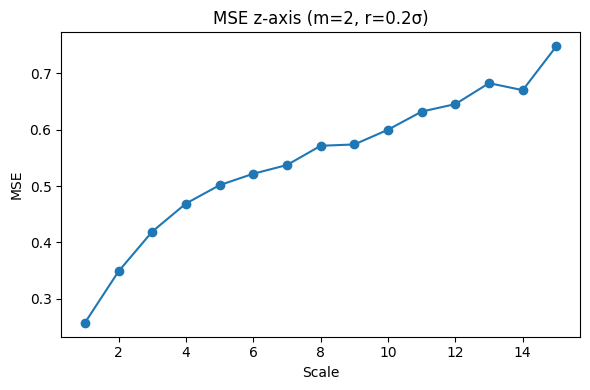

In [79]:
import pandas as pd
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
events_path  = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"Cereneo_SR_13_Fam_pre.4_events.csv"

# print("Data file:", data_path.resolve(), "Exists?", data_path.exists())

ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))
  # ← path to your events.csv
fs = 100.0                      # sampling frequency in Hz

# How many consecutive left‐leg strides you want:
N_STRIDES = 50
SKIP_SAMPLES = 5000 
skip_time = SKIP_SAMPLES / fs
df = pd.read_csv(events_path)

# Make sure we have the expected columns
required_cols = {'time', 'label', 'context', 'icon_id'}
if not required_cols.issubset(df.columns):
    raise ValueError(
        f"Expected columns {required_cols} in events.csv, but got {df.columns.tolist()}"
    )



left_fo_df = df[
    (df["context"] == "Left")
    & (df["label"]   == "Foot Off")
    & (df["time"]    >= skip_time)
].copy()

left_fo_df.sort_values(by="time", inplace=True)

if len(left_fo_df) < N_STRIDES:
    raise ValueError(
        f"Found only {len(left_fo_df)} left‐leg foot‐off events, but need {N_STRIDES}."
    )

first_n = left_fo_df.iloc[:N_STRIDES]

start_time = first_n["time"].iloc[0]
end_time   = first_n["time"].iloc[-1]

print(f"Using the first {N_STRIDES} left‐leg FOOT‐OFF events:")
print(f"  Start time (1st L_FO) = {start_time:.4f} s")
print(f"  End   time ({N_STRIDES}th L_FO) = {end_time:.4f} s")

com = ds["markers"].sel(channel="COM")

fs = 100.0


for axis in ("x", "y", "z"):
    print(f"--- {axis}-axis ---")
    ts_raw = com.sel(axis=axis).values.ravel()
    ts = preprocess_signal_entropy(ts_raw, fs)
    print(ts[::])
    start = int(start_time * fs)
    end = int(end_time * fs)
    print(f"Start index: {start}, End index: {end}")
    ts = ts[start:end]
    print(f"Signal length: {len(ts)} samples")
    
    
    r = 0.2 * np.std(ts)

    
    
    # ap_ac, samp_ac = compute_entropy_on_acceleration(ts, fs)
    # mse_ac = compute_MSE_on_acceleration(ts, fs)
    # print(f"ApEn   (m=2, r=0.2σ) = {ap_ac:.4f}")
    # print(f"SampEn (m=2, r=0.2σ) = {samp_ac:.4f}")
    # print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse_ac}")

    

    ap = approximate_entropy(ts, m=2, r=r)
    print(f"ApEn   (m=2, r=0.2σ) = {ap:.4f}")
    samp = sample_entropy(ts, m=2, r=r)
    print(f"SampEn (m=2, r=0.2σ) = {samp:.4f}")
    scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=15)
    print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse}")
    

    # Multiscale Entropy (MSE)
    scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=15)
    plt.figure(figsize=(6,4))
    plt.plot(scales, mse, 'o-')
    plt.title(f"MSE {axis}-axis (m=2, r=0.2σ)")
    plt.xlabel("Scale")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()
    print()

